In [1]:
import pandas as pd

In [2]:

agents = pd.read_csv("NIL_Agents_Cleaned.csv")
clients = pd.read_csv("NIL_Clients.csv")
link = pd.read_csv("NIL_AgentClientLink.csv")

agents.head()

,First Name,Last Name,Contact details,Client List,NBPA Certification Date,NCAA Certification Date,Certification Location,Emails,Phone Numbers,Websites
0,Brandon,Yude Abdala,"N/a Self-employed 1163 w 70th pl Hialeah, Flor...",Unknown,03/09/2022,01/29/2025,Florida,abdalabrandon@yahoo.com,(786)436-9996,NaN
1,Barry,Aberdeen,On Point Sports Management P.O Box 81 Bryans R...,Alan Griffin\n \n ...,02/12/2021,12/16/2024,NaN,onpointsportsmanagement@gmail.com,"(301)257-1716, (240)668-4241",www.onpointsportsmanagement.com
2,Fredrick,Theodore Archer,"TAA 4780 Valley Forge Lane N Minneapolis, Minn...",Unknown,02/12/2021,12/12/2024,NaN,teddyarcher@gmail.com,(612)876-6743,www.taa-sports.com/
3,Richard,Beda,", CAA Sports 405 Lexington Avenue, 19th Fl New...",Ashton Hagans\n \n ...,03/08/2016,01/09/2025,"Alabama Georgia, Kentucky Show",richard.beda@caa.com,"(917) 648-9061, (917) 384-8491",Www.caa.com
4,Eric,Brest,"600 Spring Garden Streets, Suite 202 Philadepl...",Unknown,09/23/2016,12/02/2024,"Florida New York, North Carolina",ebbrest@gmail.com,"(310) 800-1425, (310)800-1425",www.ggbasketball.com/Elevate


In [3]:
clients.head()

,Client Key,Client Full Name,Client First Name,Client Last Name,Client Suffix
0,alan griffin|,Alan Griffin,Alan,Griffin,NaN
1,anthony walker|,Anthony Walker,Anthony,Walker,NaN
2,ariana moorer|,Ariana Moorer,Ariana,Moorer,NaN
3,asia strong|,Asia Strong,Asia,Strong,NaN
4,asianae johnson|,Asianae Johnson,Asianae,Johnson,NaN


In [4]:
link.head()

,First Name,Last Name,Contact details,NBPA Certification Date,NCAA Certification Date,Certification Location,Client Key
0,Barry,Aberdeen,On Point Sports Management P.O Box 81 Bryans R...,02/12/2021,12/16/2024,NaN,alan griffin|
1,Barry,Aberdeen,On Point Sports Management P.O Box 81 Bryans R...,02/12/2021,12/16/2024,NaN,anthony walker|
2,Barry,Aberdeen,On Point Sports Management P.O Box 81 Bryans R...,02/12/2021,12/16/2024,NaN,ariana moorer|
3,Barry,Aberdeen,On Point Sports Management P.O Box 81 Bryans R...,02/12/2021,12/16/2024,NaN,asia strong|
4,Barry,Aberdeen,On Point Sports Management P.O Box 81 Bryans R...,02/12/2021,12/16/2024,NaN,asianae johnson|


In [5]:
agent_counts = pd.read_csv("NIL_Agents_ByAgent_Counts.csv")
agent_counts.describe()

,Client Count
count,68.000000
mean,12.661765
std,18.873191
min,1.000000
25%,3.750000
50%,8.000000
75%,16.000000
max,143.000000


In [6]:
agent_counts.head()

,First Name,Last Name,Client Count
0,William,David Neff,143
1,Edward,Cullen Grochowiak,57
2,Adam,Godes,36
3,Samuel,Kenneth Permut,28
4,Jeffrey,Michael Potter,26


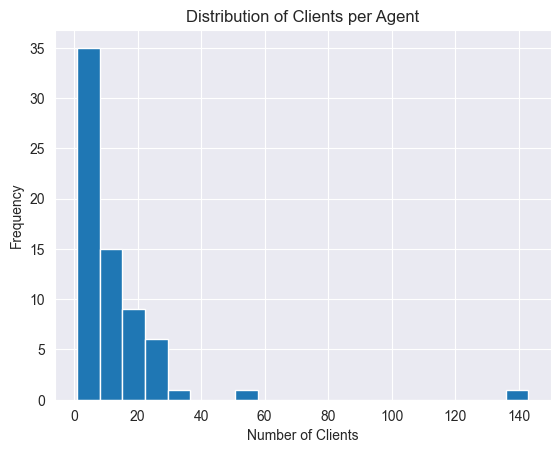

In [7]:
import matplotlib.pyplot as plt

plt.hist(agent_counts['Client Count'], bins=20)
plt.title("Distribution of Clients per Agent")
plt.xlabel("Number of Clients")
plt.ylabel("Frequency")
plt.show()

In [8]:
link['agent_name'] = link['First Name'] + " " + link['Last Name']

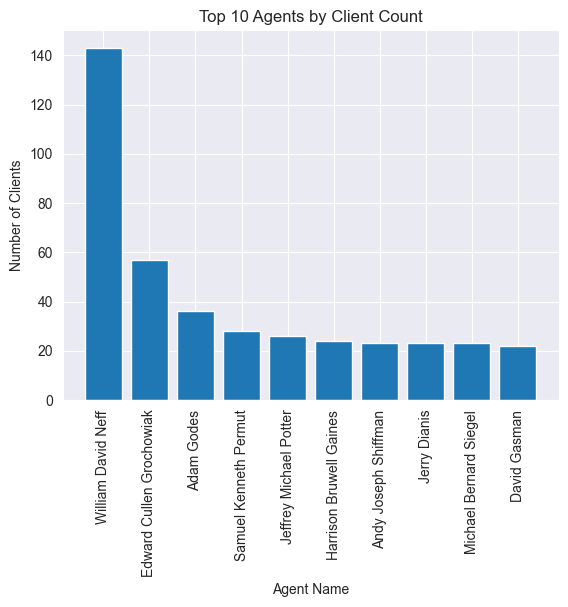

In [9]:
# 创建 agent_name
agent_counts['agent_name'] = (
    agent_counts['First Name'] + " " + agent_counts['Last Name']
)

# 取 Top 10
top10 = agent_counts.sort_values(
    by='Client Count',
    ascending=False
).head(10)

# 画图
plt.figure()
plt.bar(top10['agent_name'], top10['Client Count'])
plt.xticks(rotation=90)
plt.title("Top 10 Agents by Client Count")
plt.xlabel("Agent Name")
plt.ylabel("Number of Clients")
plt.show()

In [10]:
total_clients = agent_counts['Client Count'].sum()
top10_clients = top10['Client Count'].sum()

percentage = (top10_clients / total_clients) * 100
percentage

np.float64(47.038327526132406)

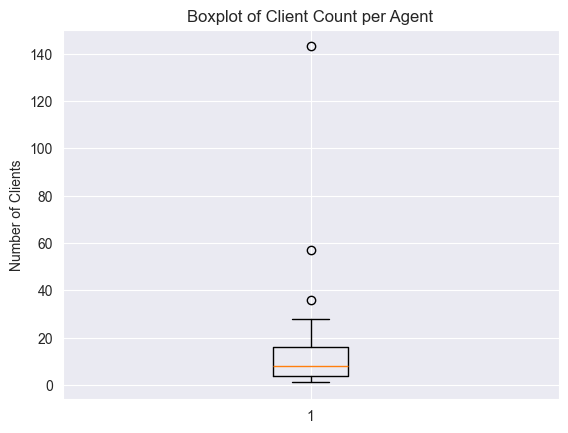

In [12]:
plt.figure()
plt.boxplot(agent_counts['Client Count'])
plt.title("Boxplot of Client Count per Agent")
plt.ylabel("Number of Clients")
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

X = agent_counts[['Client Count']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

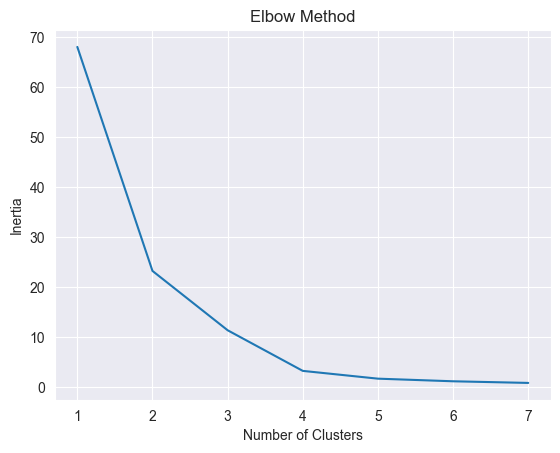

In [14]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 8), inertia)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
agent_counts['cluster'] = kmeans.fit_predict(X_scaled)

In [16]:
agent_counts.groupby('cluster')['Client Count'].mean()

cluster
0      9.615385
1    143.000000
2     46.500000
Name: Client Count, dtype: float64

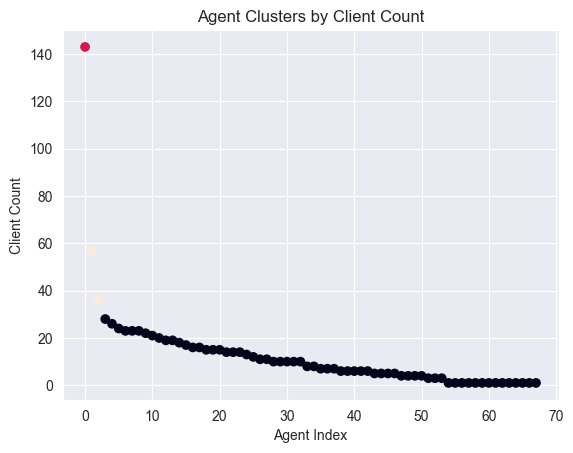

In [17]:
plt.figure()
plt.scatter(agent_counts.index, agent_counts['Client Count'],
            c=agent_counts['cluster'])
plt.title("Agent Clusters by Client Count")
plt.xlabel("Agent Index")
plt.ylabel("Client Count")
plt.show()

In [18]:
import numpy as np

# 计算总 client 数
total_clients = agent_counts['Client Count'].sum()

# 计算市场份额
agent_counts['market_share'] = agent_counts['Client Count'] / total_clients

# 计算 HHI
hhi = np.sum(agent_counts['market_share'] ** 2)

# 转换为 0–10000 标准尺度
hhi_10000 = hhi * 10000

print("HHI (Client-based):", round(hhi_10000, 2))

HHI (Client-based): 468.99


In [19]:
from datetime import datetime

# 转换日期
link['NBPA Certification Date'] = pd.to_datetime(
    link['NBPA Certification Date'], errors='coerce'
)

link['NCAA Certification Date'] = pd.to_datetime(
    link['NCAA Certification Date'], errors='coerce'
)

In [20]:
today = datetime.today()

link['tenure_years'] = (
    (today - link['NBPA Certification Date']).dt.days / 365
)

# 计算每个 agent 的平均 tenure
agent_tenure = (
    link.groupby(['First Name','Last Name'])['tenure_years']
    .mean()
    .reset_index()
)

In [21]:
today = datetime.today()

link['tenure_years'] = (
    (today - link['NBPA Certification Date']).dt.days / 365
)

# 计算每个 agent 的平均 tenure
agent_tenure = (
    link.groupby(['First Name','Last Name'])['tenure_years']
    .mean()
    .reset_index()
)

In [22]:
link['dual_cert'] = (
    link['NBPA Certification Date'].notna() &
    link['NCAA Certification Date'].notna()
).astype(int)

agent_dual = (
    link.groupby(['First Name','Last Name'])['dual_cert']
    .max()
    .reset_index()
)

In [23]:
# 先合并 tenure
agent_counts = agent_counts.merge(
    agent_tenure,
    on=['First Name','Last Name'],
    how='left'
)

# 再合并 dual
agent_counts = agent_counts.merge(
    agent_dual,
    on=['First Name','Last Name'],
    how='left'
)

In [24]:
agent_counts['intensity_score'] = (
    agent_counts['Client Count'] * 0.6 +
    agent_counts['tenure_years'].fillna(0) * 0.3 +
    agent_counts['dual_cert'] * 5
)

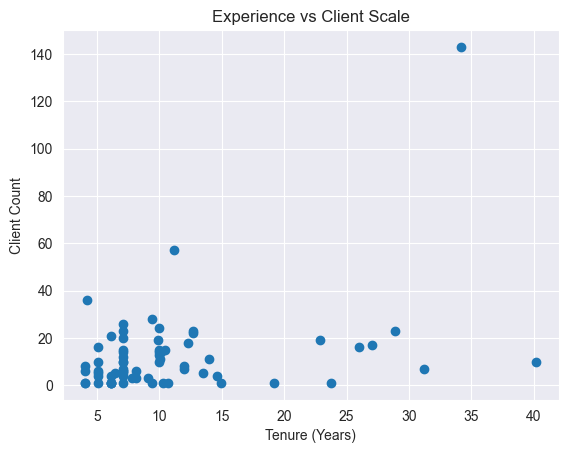

In [25]:
plt.figure()
plt.scatter(agent_counts['tenure_years'],
            agent_counts['Client Count'])
plt.xlabel("Tenure (Years)")
plt.ylabel("Client Count")
plt.title("Experience vs Client Scale")
plt.show()

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = agent_counts[
    ['Client Count','tenure_years','dual_cert']
].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
agent_counts['cluster_new'] = kmeans.fit_predict(X_scaled)

In [27]:
agent_counts.groupby('cluster_new')[
    ['Client Count','tenure_years','dual_cert']
].mean()

,Client Count,tenure_years,dual_cert
cluster_new,,,
0,10.576271,8.241690,1.0
1,11.750000,27.394178,1.0
2,143.000000,34.186301,1.0
